In [1]:
# Load Data
import numpy as np

container = np.load('split_data.npz')

# Access data
X_train = container['X_train']
y_train = container['y_train']

# Access data
X_test = container['X_test']
y_test = container['y_test']

In [2]:
# Previously I've considered the adaptative Kernel KNN, which I now changed to fixed bandwidth
from kernel_models import KernelKNN, SmoothKernels
from sklearn.metrics import r2_score

result_list = []

h_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 1e+1, 1e+2, 1e+3]
# h_list = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1] # Should have considered

for k in range(1,21):
    for h in h_list:
        # Cosine kernel
        model = KernelKNN(k=k, h=h, kernel=SmoothKernels.cosine)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_train)
        
        score = r2_score(y_train, y_pred)
    
        params = {'k': k, 'h': h, 'kernel': 'Cosine'} 
        result = {'score': score, 'params': params}
        result_list.append(result)
        
        # Epanechnikov kernel
        model = KernelKNN(k=k, h=h, kernel=SmoothKernels.epanechnikov)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_train)
        
        score = r2_score(y_train, y_pred)
    
        params = {'k': k, 'h': h, 'kernel': 'Epanechnikov'} 
        result = {'score': score, 'params': params}
        result_list.append(result)
    
        # Exponential kernel
        model = KernelKNN(k=k, h=h, kernel=SmoothKernels.exponential)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_train)
        
        score = r2_score(y_train, y_pred)
    
        params = {'k': k, 'h': h, 'kernel': 'Exponential'} 
        result = {'score': score, 'params': params}
        result_list.append(result)
    
        # Gaussian kernel
        model = KernelKNN(k=k, h=h, kernel=SmoothKernels.gaussian)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_train)
        
        score = r2_score(y_train, y_pred)
    
        params = {'k': k, 'h': h, 'kernel': 'Gaussian'} 
        result = {'score': score, 'params': params}
        result_list.append(result)
    
        # Triangular kernel
        model = KernelKNN(k=k, h=h, kernel=SmoothKernels.triangular)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_train)
        
        score = r2_score(y_train, y_pred)
    
        params = {'k': k, 'h': h, 'kernel': 'Triangular'} 
        result = {'score': score, 'params': params}
        result_list.append(result)
    
        # Uniform kernel
        model = KernelKNN(k=k, h=h, kernel=SmoothKernels.uniform)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_train)
        
        score = r2_score(y_train, y_pred)
    
        params = {'k': k, 'h': h, 'kernel': 'Uniform'} 
        result = {'score': score, 'params': params}
        result_list.append(result)

best_result = max(result_list, key=lambda x: x['score'])

print(f"Max Score: {best_result['score']}")
print(f"Best Params: {best_result['params']}")

Max Score: 0.9110307486537665
Best Params: {'k': 7, 'h': 1, 'kernel': 'Triangular'}


In [6]:
result_list.sort(key=lambda x: x['score'], reverse=True)
result_list[:10]

[{'score': 0.9110307486537665,
  'params': {'k': 7, 'h': 1, 'kernel': 'Triangular'}},
 {'score': 0.9110117078789884,
  'params': {'k': 7, 'h': 1, 'kernel': 'Exponential'}},
 {'score': 0.9109377008130753,
  'params': {'k': 9, 'h': 1, 'kernel': 'Triangular'}},
 {'score': 0.9109069425640093,
  'params': {'k': 9, 'h': 1, 'kernel': 'Exponential'}},
 {'score': 0.9109012638365132,
  'params': {'k': 7, 'h': 2, 'kernel': 'Triangular'}},
 {'score': 0.910896515468199,
  'params': {'k': 7, 'h': 2, 'kernel': 'Exponential'}},
 {'score': 0.910876849136926,
  'params': {'k': 8, 'h': 1, 'kernel': 'Triangular'}},
 {'score': 0.9108595583128153,
  'params': {'k': 7, 'h': 3, 'kernel': 'Triangular'}},
 {'score': 0.9108573678769329,
  'params': {'k': 7, 'h': 3, 'kernel': 'Exponential'}},
 {'score': 0.9108515130295972,
  'params': {'k': 8, 'h': 1, 'kernel': 'Exponential'}}]

In [7]:
from kernel_models import KernelKNN, SmoothKernels
from sklearn.metrics import r2_score

model = KernelKNN(k=7, h=1, kernel=SmoothKernels.triangular)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))

0.9065219833902005


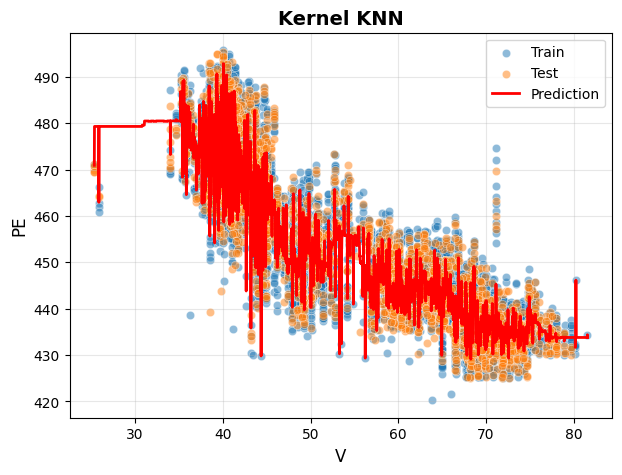

In [5]:
from utils import plot_predictions

step = 0.01
X_min = min(X_train.min(), X_test.min())
X_max = max(X_train.max(), X_test.max())
X_line = np.arange(X_min, X_max + step, step).reshape(-1, 1)
y_line = model.predict(X_line)

plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='Kernel KNN', name='Images/kernel_knn.png')